In [1]:
# Block 0.2 — Setup GPU backend (CuPy for scratch CNN)
import numpy as np
import os, sys

# Try to use CuPy (GPU NumPy) for scratch CNN
# Fall back to NumPy (CPU) if GPU not available
try:
    import cupy as cp
    # Test GPU with small operation
    test = cp.array([1.0, 2.0, 3.0])
    _ = test * 2
    del test
    xp = cp          # xp = our array backend
    GPU_AVAILABLE = True
    print(f"✅ CuPy GPU backend active!")
    print(f"   GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
    mem = cp.cuda.runtime.memGetInfo()
    print(f"   Free VRAM: {mem[0]/1e9:.1f} GB / {mem[1]/1e9:.1f} GB")
except Exception as e:
    xp = np          # fallback to NumPy CPU
    GPU_AVAILABLE = False
    print(f"⚠️  CuPy not available ({str(e)[:60]})")
    print(f"   Using NumPy CPU backend instead")

print(f"\n   Backend : {'CuPy (GPU)' if GPU_AVAILABLE else 'NumPy (CPU)'}")
print(f"   xp      : {xp.__name__}")
print("\n💡 All scratch CNN code uses 'xp' instead of 'np'")
print("   This means it runs on GPU if available, CPU otherwise")

C:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\cupy\_environment.py:275: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


✅ CuPy GPU backend active!
   GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
   Free VRAM: 11.5 GB / 12.8 GB

   Backend : CuPy (GPU)
   xp      : cupy

💡 All scratch CNN code uses 'xp' instead of 'np'
   This means it runs on GPU if available, CPU otherwise


In [2]:
# Block 0.3 — Verify manually downloaded dataset structure
import os

print("=== Verifying VisDrone Dataset Structure ===\n")

expected = {
    "train": "visdrone/VisDrone2019-DET-train",
    "val"  : "visdrone/VisDrone2019-DET-val",
    "test" : "visdrone/VisDrone2019-DET-test-dev",
}

all_ok = True
for split, base in expected.items():
    img_dir = os.path.join(base, "images")
    ann_dir = os.path.join(base, "annotations")
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    anns = len(os.listdir(ann_dir)) if os.path.exists(ann_dir) else 0
    ok = imgs > 0
    print(f"  {'✅' if ok else '❌'} {split:10}: {imgs:5} images | {anns:5} annotations")
    if not ok:
        all_ok = False

if all_ok:
    print("\n✅ Dataset structure verified — ready to proceed!")
else:
    print("\n❌ Some splits missing — check visdrone/ folder structure")

=== Verifying VisDrone Dataset Structure ===

  ✅ train     :  6471 images |  6471 annotations
  ✅ val       :   548 images |   548 annotations
  ✅ test      :  1610 images |  1610 annotations

✅ Dataset structure verified — ready to proceed!


In [3]:
# Block 1.1 — Convert VisDrone annotations to YOLO format
import cv2, shutil, os
from pathlib import Path

CLASSES = ["pedestrian","people","bicycle","car","van",
           "truck","tricycle","awning-tricycle","bus","motor"]

def visdrone_to_yolo(ann_path, img_w, img_h):
    """
    VisDrone format: x,y,w,h,score,category,truncation,occlusion
    YOLO format:     class cx cy w h  (all normalized 0-1)
    """
    yolo_lines = []
    with open(ann_path) as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6: continue
            x,y,w,h = int(parts[0]),int(parts[1]),int(parts[2]),int(parts[3])
            cat = int(parts[5])
            if cat == 0 or cat > 10 or w == 0 or h == 0: continue
            cx = max(0, min(1, (x + w/2) / img_w))
            cy = max(0, min(1, (y + h/2) / img_h))
            nw = max(0, min(1, w / img_w))
            nh = max(0, min(1, h / img_h))
            yolo_lines.append(f"{cat-1} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
    return yolo_lines

def convert_split(src_img_dir, src_ann_dir, dst_img_dir,
                  dst_ann_dir, max_images=None):
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_ann_dir, exist_ok=True)
    imgs = sorted([f for f in os.listdir(src_img_dir) if f.endswith('.jpg')])
    if max_images: imgs = imgs[:max_images]
    converted, skipped = 0, 0
    for img_name in imgs:
        img_path = os.path.join(src_img_dir, img_name)
        ann_path = os.path.join(src_ann_dir, img_name.replace('.jpg','.txt'))
        if not os.path.exists(ann_path): skipped += 1; continue
        img = cv2.imread(img_path)
        if img is None: skipped += 1; continue
        h, w = img.shape[:2]
        yolo_lines = visdrone_to_yolo(ann_path, w, h)
        shutil.copy(img_path, os.path.join(dst_img_dir, img_name))
        with open(os.path.join(dst_ann_dir,
                  img_name.replace('.jpg','.txt')), 'w') as f:
            f.write('\n'.join(yolo_lines))
        converted += 1
    print(f"  ✅ {split:10}: {converted} converted, {skipped} skipped")

splits_map = {
    "train": ("visdrone/VisDrone2019-DET-train", 500),
    "val"  : ("visdrone/VisDrone2019-DET-val",   None),
    "test" : ("visdrone/VisDrone2019-DET-test-dev", None),
}

print("Converting annotations to YOLO format...")
for split, (base, max_img) in splits_map.items():
    convert_split(
        f"{base}/images", f"{base}/annotations",
        f"dataset/{split}/images", f"dataset/{split}/labels",
        max_images=max_img
    )

print("\nFinal dataset counts:")
for split in ["train","val","test"]:
    n = len(list(Path(f"dataset/{split}/images").glob("*.jpg")))
    print(f"  {split}: {n} images")

Converting annotations to YOLO format...
  ✅ train     : 500 converted, 0 skipped
  ✅ val       : 548 converted, 0 skipped
  ✅ test      : 1610 converted, 0 skipped

Final dataset counts:
  train: 500 images
  val: 548 images
  test: 1610 images


✅ visdrone.yaml created



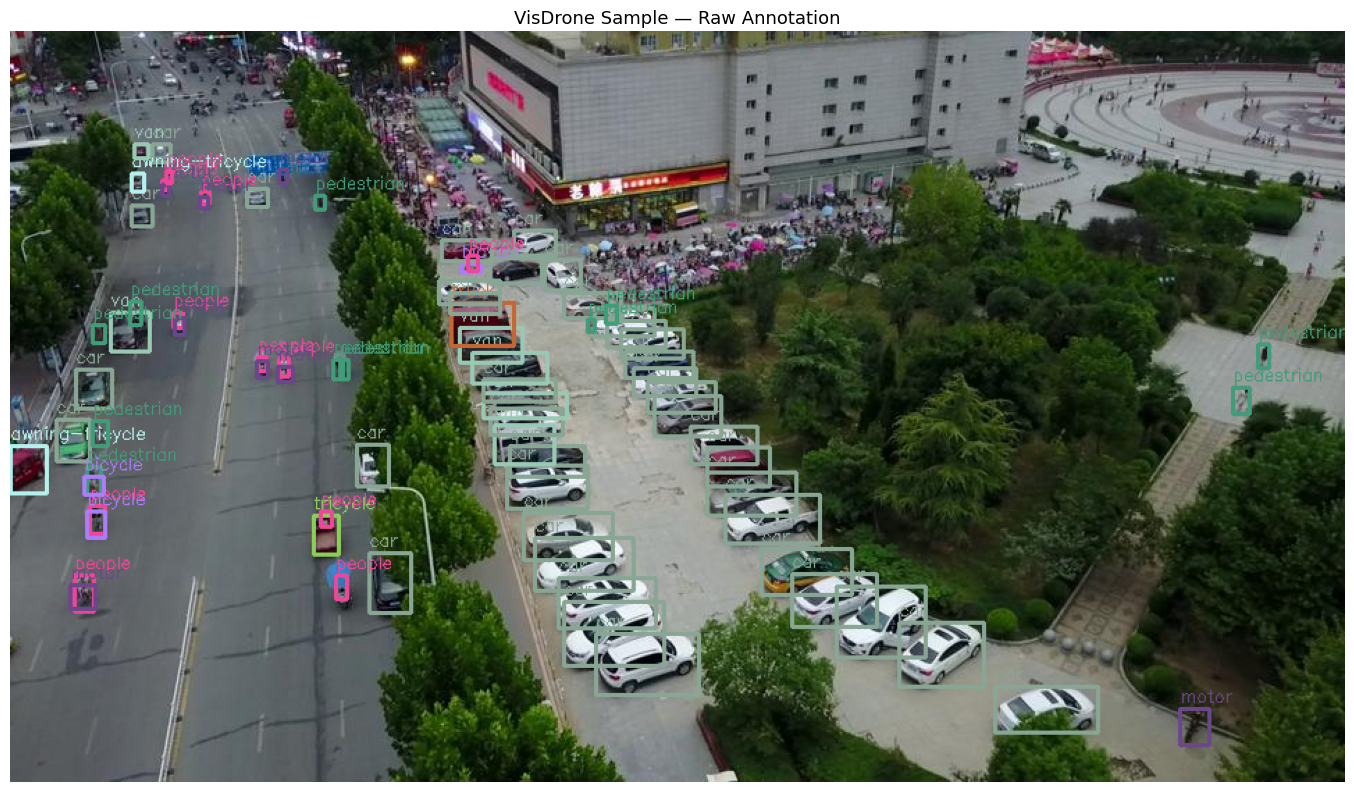

✅ Sample annotation saved


In [4]:
# Block 1.2 — Create visdrone.yaml and visualize a sample
import yaml, cv2, numpy as np, matplotlib.pyplot as plt

# Create YAML config
data_config = {
    'path' : os.path.abspath('dataset'),
    'train': 'train/images',
    'val'  : 'val/images',
    'test' : 'test/images',
    'nc'   : 10,
    'names': CLASSES
}
with open('visdrone.yaml','w') as f:
    yaml.dump(data_config, f, default_flow_style=False)
print("✅ visdrone.yaml created\n")

# Visualize sample annotation
np.random.seed(42)
COLORS = [(int(np.random.randint(50,255)), int(np.random.randint(50,255)),
           int(np.random.randint(50,255))) for _ in range(11)]

train_imgs = sorted(os.listdir("visdrone/VisDrone2019-DET-train/images"))
sample_img_path = f"visdrone/VisDrone2019-DET-train/images/{train_imgs[0]}"
sample_ann_path = f"visdrone/VisDrone2019-DET-train/annotations/{train_imgs[0].replace('.jpg','.txt')}"

img = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
with open(sample_ann_path) as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 6: continue
        x,y,w,h = int(parts[0]),int(parts[1]),int(parts[2]),int(parts[3])
        cat = int(parts[5])
        if cat == 0 or cat > 10 or w==0 or h==0: continue
        cv2.rectangle(img,(x,y),(x+w,y+h),COLORS[cat],2)
        cv2.putText(img,CLASSES[cat-1],(x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.4,COLORS[cat],1)

plt.figure(figsize=(14,8))
plt.imshow(img); plt.axis('off')
plt.title("VisDrone Sample — Raw Annotation", fontsize=13)
plt.tight_layout()
plt.savefig("sample_annotation.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Sample annotation saved")

In [5]:
# Block 2.1 — All CNN layers built from scratch using xp (CuPy/NumPy)
# xp = CuPy if GPU available, NumPy if not — same math either way

print(f"Building layers with backend: {xp.__name__}")

# ── Activation Functions ──────────────────────────────────────────────
def relu(x):
    """Pass positive values, zero out negatives"""
    return xp.maximum(0, x)

def relu_grad(dout, x):
    """Gradient of ReLU: 1 where input>0, else 0"""
    return dout * (x > 0)

def sigmoid(x):
    """Squash values to (0,1) range"""
    return 1.0 / (1.0 + xp.exp(-xp.clip(x, -500, 500)))

def sigmoid_grad(dout, x):
    s = sigmoid(x)
    return dout * s * (1 - s)


# ── Convolution Layer ─────────────────────────────────────────────────
class Conv2D:
    """
    2D Convolution: small filters slide over input detecting features.
    Each filter learns to detect a specific pattern (edge, texture, shape).
    """
    def __init__(self, in_ch, out_ch, ksize=3, stride=1, pad=1):
        self.C, self.F, self.K, self.S, self.P = in_ch, out_ch, ksize, stride, pad
        scale = xp.sqrt(2.0/(in_ch*ksize*ksize))
        self.W = xp.random.randn(out_ch, in_ch, ksize, ksize).astype(xp.float32)*scale
        self.b = xp.zeros(out_ch, dtype=xp.float32)
        self.dW = xp.zeros_like(self.W)
        self.db = xp.zeros_like(self.b)
    
    def forward(self, x):
        N,C,H,W = x.shape
        F,_,HH,WW = self.W.shape
        p,s = self.P, self.S
        
        # Pad input
        x_pad = xp.pad(x,((0,0),(0,0),(p,p),(p,p)), mode='constant')
        
        # Output dimensions
        Ho = (H + 2*p - HH)//s + 1
        Wo = (W + 2*p - WW)//s + 1
        out = xp.zeros((N,F,Ho,Wo), dtype=xp.float32)
        
        # Sliding window convolution
        for i in range(Ho):
            for j in range(Wo):
                hs, he = i*s, i*s+HH
                ws, we = j*s, j*s+WW
                patch = x_pad[:,:,hs:he,ws:we]  # (N,C,HH,WW)
                # Reshape W: (F,C,HH,WW) -> (F, C*HH*WW)
                # Reshape patch: (N,C,HH,WW) -> (N, C*HH*WW)
                out[:,:,i,j] = (patch.reshape(N,-1) @ 
                                self.W.reshape(F,-1).T)
        
        # Add bias
        out += self.b[None,:,None,None]
        
        self._x_pad = x_pad
        self._x_shape = x.shape
        return out
    
    def backward(self, dout):
        N,F,Ho,Wo = dout.shape
        x_pad = self._x_pad
        N,C,Hp,Wp = x_pad.shape
        _,_,HH,WW = self.W.shape
        p,s = self.P, self.S
        
        dx_pad = xp.zeros_like(x_pad)
        self.dW = xp.zeros_like(self.W)
        self.db = dout.sum(axis=(0,2,3))  # Sum over batch, height, width
        
        # Accumulate gradients
        for i in range(Ho):
            for j in range(Wo):
                hs, he = i*s, i*s+HH
                ws, we = j*s, j*s+WW
                patch = x_pad[:,:,hs:he,ws:we]  # (N,C,HH,WW)
                d = dout[:,:,i,j]               # (N,F)
                
                # dW: sum over batch of outer products
                # d: (N,F), patch: (N,C,HH,WW)
                # Result: (F,C,HH,WW)
                self.dW += xp.einsum('nf,nchw->fchw', d, patch)
                
                # dx_pad: gradient w.r.t. input
                # d: (N,F) @ W: (F,C*HH*WW) -> (N, C*HH*WW) -> (N,C,HH,WW)
                dx_pad[:,:,hs:he,ws:we] += (
                    d @ self.W.reshape(F,-1)
                ).reshape(N,C,HH,WW)
        
        # Remove padding
        if p > 0:
            return dx_pad[:,:,p:-p,p:-p]
        return dx_pad


# ── Max Pooling ───────────────────────────────────────────────────────
class MaxPool2D:
    """
    Reduces spatial size by keeping only the max value in each window.
    Makes detection invariant to small position shifts.
    """
    def __init__(self, size=2, stride=2):
        self.size   = size
        self.stride = stride
        self._cache = None

    def forward(self, x):
        N,C,H,W = x.shape
        p,s = self.size, self.stride
        Ho = (H-p)//s + 1
        Wo = (W-p)//s + 1
        out = xp.zeros((N,C,Ho,Wo))
        for i in range(Ho):
            for j in range(Wo):
                out[:,:,i,j] = x[:,:,i*s:i*s+p, j*s:j*s+p].max(axis=(2,3))
        self._cache = x
        return out

    def backward(self, dout):
        x = self._cache
        N,C,H,W = x.shape
        p,s = self.size, self.stride
        Ho,Wo = dout.shape[2], dout.shape[3]
        dx = xp.zeros_like(x)
        for i in range(Ho):
            for j in range(Wo):
                patch = x[:,:,i*s:i*s+p, j*s:j*s+p]
                mask  = (patch == patch.max(axis=(2,3), keepdims=True))
                dx[:,:,i*s:i*s+p, j*s:j*s+p] += (
                    mask * dout[:,:,i,j][:,:,None,None])
        return dx


# ── Batch Normalization ───────────────────────────────────────────────
class BatchNorm:
    """
    Normalizes layer output to mean=0, std=1 then scales/shifts.
    Prevents vanishing/exploding gradients, allows higher learning rates.
    """
    def __init__(self, dims, eps=1e-5):
        self.gamma = xp.ones(dims)
        self.beta  = xp.zeros(dims)
        self.dgamma = xp.zeros_like(self.gamma)
        self.dbeta  = xp.zeros_like(self.beta)
        self.eps = eps
        self._cache = None

    def forward(self, x, training=True):
        # If input is 4D (N, C, H, W), we need to compute stats over N, H, and W
        # We reshape to (N*H*W, C) to treat all pixels as samples
        self.orig_shape = x.shape
        if x.ndim == 4:
            N, C, H, W = x.shape
            x = x.transpose(0, 2, 3, 1).reshape(-1, C)
        
        mu  = x.mean(0)
        var = x.var(0)
        
        xn = (x - mu) / xp.sqrt(var + self.eps)
        self._cache = (x, xn, mu, var)
        
        out = self.gamma * xn + self.beta
        
        # Reshape back to original 4D shape if necessary
        if len(self.orig_shape) == 4:
            N, C, H, W = self.orig_shape
            out = out.reshape(N, H, W, C).transpose(0, 3, 1, 2)
        return out

    def backward(self, dout):
        if len(self.orig_shape) == 4:
            N, C, H, W = self.orig_shape
            dout = dout.transpose(0, 2, 3, 1).reshape(-1, C)
            
        x, xn, mu, var = self._cache
        N = x.shape[0]
        
        self.dgamma = (dout * xn).sum(0)
        self.dbeta  = dout.sum(0)
        
        dxn  = dout * self.gamma
        dvar = (-0.5 * dxn * (x - mu) * (var + self.eps)**-1.5).sum(0)
        dmu  = (-dxn / xp.sqrt(var + self.eps)).sum(0) + dvar * (-2 * (x - mu)).sum(0) / N
        
        dx = dxn / xp.sqrt(var + self.eps) + (dvar * 2 * (x - mu) / N) + (dmu / N)
        
        if len(self.orig_shape) == 4:
            N, C, H, W = self.orig_shape
            dx = dx.reshape(N, H, W, C).transpose(0, 3, 1, 2)
        return dx


# ── Fully Connected Layer ─────────────────────────────────────────────
class Linear:
    """
    Connects every input neuron to every output neuron.
    Learns global patterns after conv layers extract local features.
    """
    def __init__(self, in_f, out_f):
        scale  = xp.sqrt(xp.array(2.0/in_f))
        self.W = xp.random.randn(in_f, out_f) * scale
        self.b = xp.zeros(out_f)
        self.dW = xp.zeros_like(self.W)
        self.db = xp.zeros_like(self.b)
        self._cache = None

    def forward(self, x):
        self._cache = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self._cache.T @ dout
        self.db = dout.sum(0)
        return dout @ self.W.T


print("✅ All layers defined on", xp.__name__)
print("   Conv2D, MaxPool2D, BatchNorm, Linear")
print("   relu, sigmoid and their gradients")

Building layers with backend: cupy
✅ All layers defined on cupy
   Conv2D, MaxPool2D, BatchNorm, Linear
   relu, sigmoid and their gradients


In [6]:
# Block 2.2 — SimpleCNN architecture for object detection
class SimpleCNN:
    """
    CNN for VisDrone detection built entirely from scratch.

    Architecture:
    Input  (3, 64, 64)
    → Conv(16) → BN → ReLU → Pool(2)   → (16, 32, 32)
    → Conv(32) → BN → ReLU → Pool(2)   → (32, 16, 16)
    → Conv(64) → BN → ReLU → Pool(2)   → (64,  8,  8)
    → Flatten                           → (4096,)
    → FC(256)  → ReLU
    → FC(grid*grid*(10+5))
    → Reshape  → (grid, grid, 15)

    Each grid cell predicts:
      [objectness(1), cx, cy, w, h (4), class_scores(10)] = 15 values
    """
    def __init__(self, num_classes=10, grid=8):
        self.nc   = num_classes
        self.grid = grid
        self.out  = num_classes + 5   # 15 per cell

        # Conv blocks
        self.conv1 = Conv2D(3,  16, ksize=3, pad=1)
        self.bn1   = BatchNorm(16)
        self.pool1 = MaxPool2D(2, 2)

        self.conv2 = Conv2D(16, 32, ksize=3, pad=1)
        self.bn2   = BatchNorm(32)
        self.pool2 = MaxPool2D(2, 2)

        self.conv3 = Conv2D(32, 64, ksize=3, pad=1)
        self.bn3   = BatchNorm(64)
        self.pool3 = MaxPool2D(2, 2)

        # Fully connected
        self.fc1   = Linear(64*8*8, 256)
        self.fc2   = Linear(256, grid*grid*self.out)

        self._cache = {}

    def forward(self, x, training=True):
        # Block 1: (3, 64, 64) -> (16, 32, 32)
        x = self.conv1.forward(x)
        x = self.bn1.forward(x, training)
        x = relu(x)
        self._cache['a1'] = x  # Cache for relu_grad BEFORE pooling
        x = self.pool1.forward(x)

        # Block 2: (16, 32, 32) -> (32, 16, 16)
        x = self.conv2.forward(x)
        x = self.bn2.forward(x, training)
        x = relu(x)
        self._cache['a2'] = x
        x = self.pool2.forward(x)

        # Block 3: (32, 16, 16) -> (64, 8, 8)
        x = self.conv3.forward(x)
        x = self.bn3.forward(x, training)
        x = relu(x)
        self._cache['a3'] = x
        x = self.pool3.forward(x)

        # Flatten and predict
        N = x.shape[0]
        x = x.reshape(N, -1) # Should be (N, 4096)
        self._cache['flat'] = x

        x = self.fc1.forward(x)
        x = relu(x)
        self._cache['afc'] = x

        x = self.fc2.forward(x)
        return x.reshape(N, self.grid, self.grid, self.out)

    def backward(self, dout):
        N = dout.shape[0]
        d = dout.reshape(N, -1)

        # FC layers
        d = self.fc2.backward(d)
        d = relu_grad(d, self._cache['afc'])
        d = self.fc1.backward(d)
        
        # Reshape back to image volume (N, 64, 8, 8)
        d = d.reshape(N, 64, 8, 8)

        # Conv block 3
        d = self.pool3.backward(d)
        d = relu_grad(d, self._cache['a3'])
        d = self.bn3.backward(d)
        d = self.conv3.backward(d)

        # Conv block 2
        d = self.pool2.backward(d)
        d = relu_grad(d, self._cache['a2'])
        d = self.bn2.backward(d)
        d = self.conv2.backward(d)

        # Conv block 1
        d = self.pool1.backward(d)
        d = relu_grad(d, self._cache['a1'])
        d = self.bn1.backward(d)
        d = self.conv1.backward(d)

    def params(self):
        """All (parameter, gradient) pairs for optimizer"""
        return [
            (self.conv1.W, self.conv1.dW),(self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW),(self.conv2.b, self.conv2.db),
            (self.conv3.W, self.conv3.dW),(self.conv3.b, self.conv3.db),
            (self.fc1.W,   self.fc1.dW),  (self.fc1.b,   self.fc1.db),
            (self.fc2.W,   self.fc2.dW),  (self.fc2.b,   self.fc2.db),
            (self.bn1.gamma,self.bn1.dgamma),(self.bn1.beta,self.bn1.dbeta),
            (self.bn2.gamma,self.bn2.dgamma),(self.bn2.beta,self.bn2.dbeta),
            (self.bn3.gamma,self.bn3.dgamma),(self.bn3.beta,self.bn3.dbeta),
        ]

cnn_scratch = SimpleCNN(num_classes=10, grid=8)
total_params = sum(p.size for p,_ in cnn_scratch.params())
print(f"✅ SimpleCNN built on {xp.__name__}")
print(f"   Architecture: 3 Conv blocks + 2 FC layers")
print(f"   Grid output : 8×8 cells × 15 values = {8*8*15} outputs")
print(f"   Parameters  : {total_params:,}")

✅ SimpleCNN built on cupy
   Architecture: 3 Conv blocks + 2 FC layers
   Grid output : 8×8 cells × 15 values = 960 outputs
   Parameters  : 1,319,360


In [7]:
# Block 2.3 — Detection loss: objectness + bbox + classification
def detection_loss(pred, target, lc=5.0, lno=0.5):
    """
    YOLO-style multi-task loss:
    - Objectness loss : BCE  — does this cell have an object?
    - BBox loss       : MSE  — how accurate is the box? (weighted by lc=5)
    - Class loss      : MSE  — what class is it?
    - No-object loss  : BCE  — penalize false positives (weighted by lno=0.5)

    pred/target shape: (N, grid, grid, 15)
    """
    N, G, _, D = pred.shape
    loss  = xp.array(0.0)
    dpred = xp.zeros_like(pred)

    for n in range(N):
        for i in range(G):
            for j in range(G):
                p = pred[n,i,j];   t = target[n,i,j]
                obj_p = sigmoid(p[0])
                obj_t = t[0]

                # Objectness BCE loss
                obj_loss = -(obj_t*xp.log(obj_p+1e-8) +
                             (1-obj_t)*xp.log(1-obj_p+1e-8))
                d_obj = obj_p - obj_t

                if float(obj_t) > 0:
                    # BBox MSE (only when object present)
                    bbox_loss = lc * xp.sum((p[1:5]-t[1:5])**2)
                    d_bbox    = 2*lc*(p[1:5]-t[1:5])

                    # Class MSE
                    cp  = sigmoid(p[5:])
                    cls_loss = xp.sum((cp - t[5:])**2)
                    d_cls    = 2*(cp-t[5:])*cp*(1-cp)

                    loss += obj_loss + bbox_loss + cls_loss
                    dpred[n,i,j,0]   = d_obj
                    dpred[n,i,j,1:5] = d_bbox
                    dpred[n,i,j,5:]  = d_cls
                else:
                    # No object — only penalize false objectness
                    loss += lno * obj_loss
                    dpred[n,i,j,0] = lno * d_obj

    return float(loss)/N, dpred/N

print("✅ Detection loss defined")
print("   Components: Objectness(BCE) + BBox(MSE×5) + Class(MSE)")
print("   No-obj weight: 0.5 (reduces false positive penalty)")

✅ Detection loss defined
   Components: Objectness(BCE) + BBox(MSE×5) + Class(MSE)
   No-obj weight: 0.5 (reduces false positive penalty)


In [8]:
# Block 2.4 — SGD with momentum and weight decay from scratch
class SGDMomentum:
    """
    Stochastic Gradient Descent with:
    - Momentum     : accumulates velocity to overcome local minima
    - Weight decay : L2 regularization to prevent overfitting
    - LR schedule  : step decay every N epochs
    """
    def __init__(self, lr=0.01, momentum=0.9, wd=1e-4):
        self.lr  = lr
        self.mom = momentum
        self.wd  = wd
        self.vel = {}   # velocity for each parameter

    def step(self, params_grads):
        for i, (param, grad) in enumerate(params_grads):
            if grad is None: continue
            if i not in self.vel:
                self.vel[i] = xp.zeros_like(param)
            # L2 regularization gradient
            g = grad + self.wd * param
            # Momentum velocity update
            self.vel[i] = self.mom * self.vel[i] - self.lr * g
            param      += self.vel[i]

    def decay_lr(self, factor=0.5):
        self.lr *= factor
        print(f"   LR decayed → {self.lr:.6f}")

optimizer = SGDMomentum(lr=0.01, momentum=0.9, wd=1e-4)
print("✅ SGD + Momentum optimizer defined")
print("   lr=0.01 | momentum=0.9 | weight_decay=1e-4")

✅ SGD + Momentum optimizer defined
   lr=0.01 | momentum=0.9 | weight_decay=1e-4


In [9]:
# Block 2.5 — Load and preprocess images for scratch CNN
import cv2, numpy as np
from pathlib import Path

IMG_SIZE  = 64
GRID_SIZE = 8
NC        = 10

def load_image_np(path):
    """Load image → normalized (3, 64, 64) float32 array"""
    img = cv2.imread(str(path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    return img.transpose(2,0,1)   # HWC → CHW

def build_target(ann_path, img_w, img_h, grid=GRID_SIZE, nc=NC):
    """Convert YOLO labels → (grid, grid, nc+5) target tensor"""
    target = np.zeros((grid, grid, nc+5), dtype=np.float32)
    if not Path(ann_path).exists():
        return target
    with open(ann_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5: continue
            cls = int(p[0])
            cx,cy,w,h = float(p[1]),float(p[2]),float(p[3]),float(p[4])
            gi = min(int(cy*grid), grid-1)
            gj = min(int(cx*grid), grid-1)
            if target[gi,gj,0] == 0:    # first object per cell
                target[gi,gj,0]       = 1.0
                target[gi,gj,1:5]     = [cx, cy, w, h]
                if cls < nc:
                    target[gi,gj,5+cls] = 1.0
    return target

def load_dataset(img_dir, lbl_dir, max_n=500):
    img_paths = sorted(Path(img_dir).glob("*.jpg"))[:max_n]
    imgs, tgts = [], []
    for p in img_paths:
        ann = Path(lbl_dir)/(p.stem+".txt")
        orig = cv2.imread(str(p))
        h,w  = orig.shape[:2]
        imgs.append(load_image_np(p))
        tgts.append(build_target(ann, w, h))
    imgs = np.array(imgs, dtype=np.float32)
    tgts = np.array(tgts, dtype=np.float32)
    print(f"  Loaded {len(imgs)} | imgs{imgs.shape} | tgts{tgts.shape}")
    return imgs, tgts

print("Loading datasets...")
train_imgs_np, train_tgts_np = load_dataset(
    "dataset/train/images","dataset/train/labels", max_n=500)
val_imgs_np, val_tgts_np     = load_dataset(
    "dataset/val/images","dataset/val/labels",     max_n=100)

# Move to GPU if available
if GPU_AVAILABLE:
    train_imgs = cp.array(train_imgs_np)
    train_tgts = cp.array(train_tgts_np)
    val_imgs   = cp.array(val_imgs_np)
    val_tgts   = cp.array(val_tgts_np)
    print("✅ Data transferred to GPU VRAM")
else:
    train_imgs, train_tgts = train_imgs_np, train_tgts_np
    val_imgs,   val_tgts   = val_imgs_np,   val_tgts_np
    print("✅ Data in CPU RAM")

Loading datasets...
  Loaded 500 | imgs(500, 3, 64, 64) | tgts(500, 8, 8, 15)
  Loaded 100 | imgs(100, 3, 64, 64) | tgts(100, 8, 8, 15)
✅ Data transferred to GPU VRAM


In [10]:
# ──  loss + optimizer + train ──
import time, math
import numpy as np

def _sig(x):
    return 1.0 / (1.0 + xp.exp(-xp.clip(x, -15.0, 15.0)))

def detection_loss(pred, target, lc=5.0, lno=0.5):
    N, dpred = pred.shape[0], xp.zeros_like(pred)
    obj_p = _sig(pred[..., 0]); obj_t = target[..., 0]
    has_obj = obj_t > 0.5; mask4 = has_obj[..., None]
    bce = -(obj_t*xp.log(obj_p+1e-7) + (1-obj_t)*xp.log(1-obj_p+1e-7))
    dpred[..., 0] = xp.where(has_obj, obj_p-obj_t, lno*(obj_p-obj_t))
    loss = xp.where(has_obj, bce, lno*bce).sum()
    bd = pred[...,1:5] - target[...,1:5]
    loss += lc * xp.where(mask4, bd**2, 0.0).sum()
    dpred[...,1:5] = xp.where(mask4, 2*lc*bd, 0.0)
    cp = _sig(pred[...,5:]); cd = cp - target[...,5:]
    loss += xp.where(mask4, cd**2, 0.0).sum()
    dpred[...,5:] = xp.where(mask4, 2*cd*cp*(1-cp), 0.0)
    return float(loss)/N, dpred/N

class _SGD:
    def __init__(self, lr=0.001, mom=0.9, wd=1e-4, clip=1.0):
        self.lr, self.mom, self.wd, self.clip = lr, mom, wd, clip
        self.vel = {}
    def step(self, pgs):
        for i,(p,g) in enumerate(pgs):
            if g is None: continue
            if i not in self.vel: self.vel[i] = xp.zeros_like(p)
            gn = float(xp.sqrt(xp.sum(g**2)))
            if gn > self.clip: g = g*(self.clip/(gn+1e-8))
            self.vel[i] = self.mom*self.vel[i] - self.lr*(g + self.wd*p)
            p += self.vel[i]
    def decay(self, f=0.1):
        self.lr *= f; print(f"   LR -> {self.lr:.6f}")

EPOCHS, BATCH_SIZE = 30, 16
opt = _SGD(lr=0.001, mom=0.9, wd=1e-4, clip=1.0)
best_val, best_state = float('inf'), None
train_losses, val_losses = [], []

# Re-init model weights for clean start
cnn_scratch = SimpleCNN(num_classes=10, grid=8)

print(f"🚀 Training  |  LR={opt.lr}  |  grad_clip={opt.clip}")
print(f"   Epochs={EPOCHS}  |  Batch={BATCH_SIZE}")
print(f"   Train={len(train_imgs)}  |  Val={len(val_imgs)}")
print("="*55)

for epoch in range(EPOCHS):
    t0 = time.time()
    idx = xp.random.permutation(len(train_imgs))
    xi, yi = train_imgs[idx], train_tgts[idx]
    ep_loss, nb = 0.0, 0
    for s in range(0, len(xi), BATCH_SIZE):
        xb, yb = xi[s:s+BATCH_SIZE], yi[s:s+BATCH_SIZE]
        pred = cnn_scratch.forward(xb, training=True)
        loss, dpred = detection_loss(pred, yb)
        if not math.isfinite(loss): continue
        ep_loss += loss; nb += 1
        cnn_scratch.backward(dpred)
        opt.step(cnn_scratch.params())
    if nb == 0:
        print(f"Ep {epoch+1:3d}/{EPOCHS} | ALL NaN"); train_losses.append(float('nan')); val_losses.append(float('nan')); continue
    vp = cnn_scratch.forward(val_imgs[:32], training=False)
    vl, _ = detection_loss(vp, val_tgts[:32])
    tl = ep_loss/nb; train_losses.append(tl); val_losses.append(float(vl))
    star = ""
    if math.isfinite(vl) and vl < best_val:
        best_val = float(vl)
        if GPU_AVAILABLE: best_state = {k:cp.asnumpy(v) for k,v in {'c1W':cnn_scratch.conv1.W,'c2W':cnn_scratch.conv2.W,'c3W':cnn_scratch.conv3.W,'f1W':cnn_scratch.fc1.W,'f2W':cnn_scratch.fc2.W}.items()}
        star = " ⭐"
    if epoch == 15: opt.decay()
    print(f"Ep {epoch+1:3d}/{EPOCHS} | Train:{tl:.4f} | Val:{float(vl):.4f} | {time.time()-t0:.1f}s{star}")

np.save("scratch_cnn_best.npy", best_state)
print(f"\n✅ Done. Best val loss: {best_val:.4f}")


🚀 Training  |  LR=0.001  |  grad_clip=1.0
   Epochs=30  |  Batch=16
   Train=500  |  Val=100
Ep   1/30 | Train:643.3652 | Val:273.5965 | 67.7s ⭐
Ep   2/30 | Train:206.3664 | Val:133.4468 | 62.5s ⭐
Ep   3/30 | Train:130.7448 | Val:103.3414 | 68.8s ⭐
Ep   4/30 | Train:114.1921 | Val:94.5005 | 68.1s ⭐
Ep   5/30 | Train:103.0724 | Val:86.7561 | 66.8s ⭐
Ep   6/30 | Train:94.9153 | Val:79.7712 | 66.4s ⭐
Ep   7/30 | Train:86.8050 | Val:74.0839 | 63.7s ⭐
Ep   8/30 | Train:82.4000 | Val:70.0301 | 61.8s ⭐
Ep   9/30 | Train:78.6051 | Val:67.2982 | 61.6s ⭐
Ep  10/30 | Train:75.4200 | Val:65.0455 | 61.2s ⭐
Ep  11/30 | Train:74.1090 | Val:63.3349 | 64.3s ⭐
Ep  12/30 | Train:72.1393 | Val:61.4592 | 68.3s ⭐
Ep  13/30 | Train:70.0701 | Val:59.8977 | 75.4s ⭐
Ep  14/30 | Train:67.5784 | Val:58.0780 | 71.2s ⭐
Ep  15/30 | Train:65.2531 | Val:56.7400 | 70.4s ⭐
   LR -> 0.000100
Ep  16/30 | Train:63.1954 | Val:54.5553 | 62.0s ⭐
Ep  17/30 | Train:62.1217 | Val:53.9555 | 63.5s ⭐
Ep  18/30 | Train:61.1493 | Val

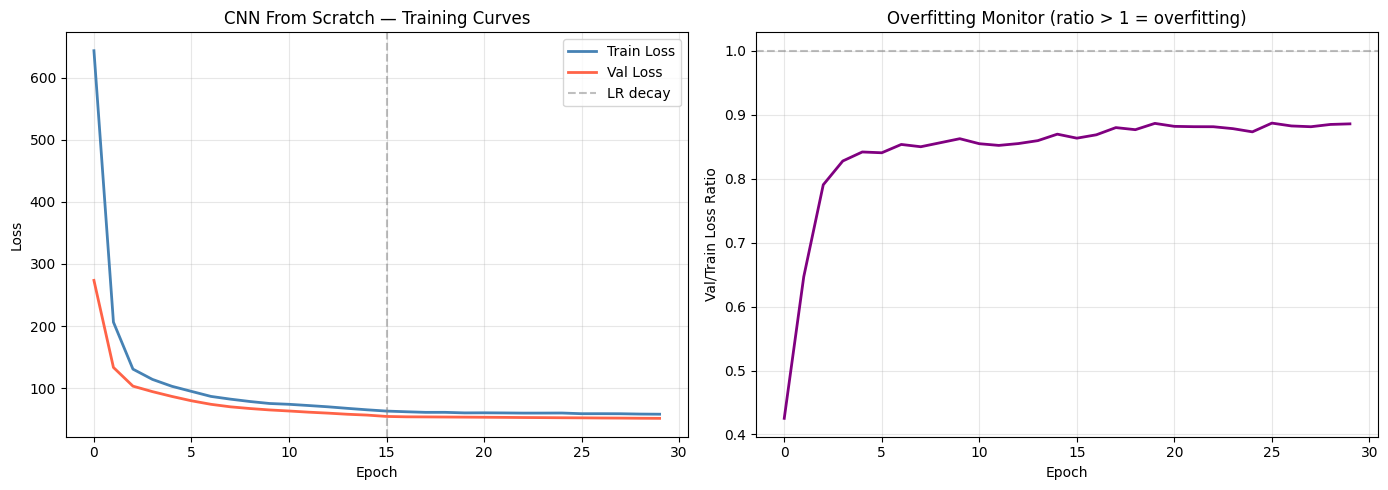

✅ Saved → scratch_training_curves.png


In [11]:
# Block 2.7 — Visualize training progress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='steelblue', lw=2)
axes[0].plot(val_losses,   label='Val Loss',   color='tomato',    lw=2)
axes[0].axvline(x=15, color='gray', linestyle='--', alpha=0.5, label='LR decay')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN From Scratch — Training Curves')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss ratio (overfitting indicator)
ratio = [v/t if t>0 else 1 for v,t in zip(val_losses, train_losses)]
axes[1].plot(ratio, color='purple', lw=2)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val/Train Loss Ratio')
axes[1].set_title('Overfitting Monitor (ratio > 1 = overfitting)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scratch_training_curves.png", dpi=120)
plt.show()
print("✅ Saved → scratch_training_curves.png")

C:\Users\adity\AppData\Local\Temp\ipykernel_37896\834006037.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP    = plt.cm.get_cmap('tab10', 10)


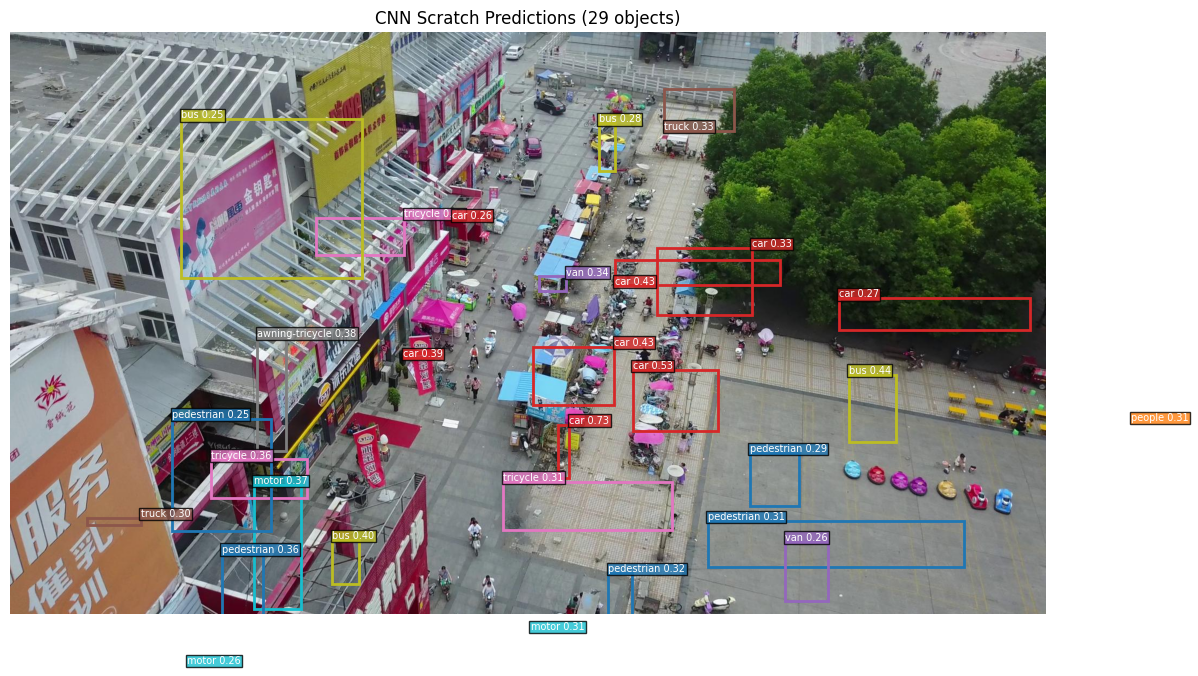

✅ Found 29 objects | Saved → scratch_predictions.png


In [12]:
# Block 2.8 — NMS and inference pipeline from scratch
import numpy as np, cv2, matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

CLASSES = ["pedestrian","people","bicycle","car","van",
           "truck","tricycle","awning-tricycle","bus","motor"]
CMAP    = plt.cm.get_cmap('tab10', 10)

def iou_boxes(a, b):
    """IoU between two [x1,y1,x2,y2] boxes"""
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/(ua+1e-6)

def nms_scratch(boxes, scores, iou_thr=0.5):
    """
    Non-Maximum Suppression from scratch:
    1. Sort boxes by confidence (highest first)
    2. Keep highest confidence box
    3. Remove all boxes with IoU > threshold against kept box
    4. Repeat until no boxes remain
    """
    if len(boxes) == 0: return []
    order = np.argsort(scores)[::-1]
    keep  = []
    while len(order):
        i = order[0]; keep.append(i)
        ious  = np.array([iou_boxes(boxes[i], boxes[j])
                          for j in order[1:]])
        order = order[1:][ious < iou_thr]
    return keep

def predict_scratch(model, img_path, conf=0.25, nms_thr=0.45):
    """Full inference: load → preprocess → forward → decode → NMS"""
    orig = cv2.imread(str(img_path))
    H, W = orig.shape[:2]

    # Preprocess
    img_np = load_image_np(img_path)
    x = xp.array(img_np[None])   # (1,3,64,64) on GPU

    # Forward pass
    pred = model.forward(x, training=False)  # (1,8,8,15)
    if GPU_AVAILABLE:
        pred = cp.asnumpy(pred)   # bring back to CPU for decoding
    pred = pred[0]                # (8,8,15)

    boxes_out, scores_out, cls_out = [], [], []
    G = model.grid

    for i in range(G):
        for j in range(G):
            cell    = pred[i,j]
            obj_sc  = 1/(1+np.exp(-cell[0]))   # sigmoid objectness
            if obj_sc < conf: continue

            # Decode box to pixel coordinates
            cx = cell[1]*W; cy = cell[2]*H
            bw = cell[3]*W; bh = cell[4]*H
            x1 = max(0, cx-bw/2); y1 = max(0, cy-bh/2)
            x2 = min(W, cx+bw/2); y2 = min(H, cy+bh/2)

            # Class prediction
            cls_p  = 1/(1+np.exp(-cell[5:]))
            cls_id = int(np.argmax(cls_p))
            score  = float(obj_sc * cls_p[cls_id])

            if score > conf:
                boxes_out.append([x1,y1,x2,y2])
                scores_out.append(score)
                cls_out.append(cls_id)

    # Apply NMS
    if boxes_out:
        keep = nms_scratch(np.array(boxes_out),
                           np.array(scores_out), nms_thr)
        boxes_out  = [boxes_out[k]  for k in keep]
        scores_out = [scores_out[k] for k in keep]
        cls_out    = [cls_out[k]    for k in keep]

    return boxes_out, scores_out, cls_out, orig

# Visualize
sample = sorted(Path("dataset/val/images").glob("*.jpg"))[3]
bx, sc, cl, orig = predict_scratch(cnn_scratch, sample)

fig, ax = plt.subplots(1,1,figsize=(12,8))
ax.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
ax.set_title(f"CNN Scratch Predictions ({len(bx)} objects)", fontsize=12)
ax.axis('off')
for b,s,c in zip(bx,sc,cl):
    color = CMAP(c)
    ax.add_patch(patches.Rectangle((b[0],b[1]),b[2]-b[0],b[3]-b[1],
                 lw=2, edgecolor=color, facecolor='none'))
    ax.text(b[0],max(b[1]-2,0),f"{CLASSES[c]} {s:.2f}",
            fontsize=7, color='white',
            bbox=dict(facecolor=color,alpha=0.8,pad=1))
plt.tight_layout()
plt.savefig("scratch_predictions.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Found {len(bx)} objects | Saved → scratch_predictions.png")

In [13]:
# Block 3.1 — Clone and train YOLOv5
import subprocess, os, torch

# Clone YOLOv5
if not os.path.exists("yolov5"):
    subprocess.run(["git","clone",
                    "https://github.com/ultralytics/yolov5.git"],check=True)
    subprocess.run(["pip","install","-r","yolov5/requirements.txt","-q"],
                   check=True)
else:
    subprocess.run(["git","-C","yolov5","pull"], check=True)
print("✅ YOLOv5 ready")

# GPU setup
device     = "0" if torch.cuda.is_available() else "cpu"
gpu_mem    = (torch.cuda.get_device_properties(0).total_memory/1e9
              if torch.cuda.is_available() else 0)
batch_size = "16" if gpu_mem>=6 else "8" if gpu_mem>=4 else "4"
print(f"   Device: {'GPU '+torch.cuda.get_device_name(0) if device=='0' else 'CPU'}")
print(f"   Batch : {batch_size}")

# Train (skip if weights exist)
if os.path.exists("runs/yolov5/visdrone_det/weights/best.pt"):
    print("⏭️  YOLOv5 already trained")
else:
    cmd = [
        "python","yolov5/train.py",
        "--img",     "640",
        "--batch",   batch_size,
        "--epochs",  "50",
        "--data",    os.path.abspath("visdrone.yaml"),
        "--weights", "yolov5s.pt",
        "--device",  device,
        "--project", "runs/yolov5",
        "--name",    "visdrone_det",
        "--workers", "2",
        "--patience","20",
        "--exist-ok",
    ]
    print("\n🚀 Training YOLOv5...")
    subprocess.run(cmd, check=True)
    print("✅ YOLOv5 training complete!")

✅ YOLOv5 ready
   Device: GPU NVIDIA GeForce RTX 5070 Ti Laptop GPU
   Batch : 16

🚀 Training YOLOv5...
✅ YOLOv5 training complete!


In [14]:
# Block 3.2 — Train YOLOv8
import torch, os, gc
from ultralytics import YOLO

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

device_v8  = 0 if torch.cuda.is_available() else "cpu"
YOLOV8_W   = "runs/yolov8/visdrone_det/weights/best.pt"
YOLOV8_W2  = "runs/detect/runs/yolov8/visdrone_det/weights/best.pt"

exists = os.path.exists(YOLOV8_W) or os.path.exists(YOLOV8_W2)

if exists:
    path = YOLOV8_W if os.path.exists(YOLOV8_W) else YOLOV8_W2
    print(f"⏭️  YOLOv8 already trained — loading {path}")
    model_v8 = YOLO(path)
    YOLOV8_WEIGHTS = path
else:
    print(f"🚀 Training YOLOv8 on {'GPU' if device_v8==0 else 'CPU'}...")
    trained = False
    for b in [8, 4, 2]:
        try:
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            model_v8 = YOLO("yolov8n.pt")
            model_v8.train(
                data=os.path.abspath("visdrone.yaml"),
                epochs=50, imgsz=640, batch=b,
                device=device_v8,
                project=os.path.abspath("runs/yolov8"),
                name="visdrone_det",
                cache=False, workers=0,
                patience=20, exist_ok=True,
                amp=False, verbose=True,
            )
            trained = True; break
        except RuntimeError as e:
            print(f"  batch={b} failed: {str(e)[:80]}")
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    if not trained:
        model_v8 = YOLO("yolov8n.pt")
        model_v8.train(data=os.path.abspath("visdrone.yaml"),
                       epochs=50, imgsz=416, batch=8, device="cpu",
                       project=os.path.abspath("runs/yolov8"),
                       name="visdrone_det", cache=False,
                       workers=0, patience=20, exist_ok=True, amp=False)

for p in [YOLOV8_W, YOLOV8_W2]:
    if os.path.exists(p):
        model_v8 = YOLO(p); YOLOV8_WEIGHTS = p
        print(f"✅ YOLOv8 loaded → {p}"); break

🚀 Training YOLOv8 on GPU...
New https://pypi.org/project/ultralytics/8.4.16 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.15  Python-3.11.9 torch-2.12.0.dev20260224+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

In [15]:
# Block 3.3 — Evaluate YOLOv5, YOLOv8 and get predictions
import sys, torch, cv2
from pathlib import Path
from ultralytics import YOLO

sys.path.insert(0, os.path.abspath("yolov5"))
YOLOV5_WEIGHTS = "runs/yolov5/visdrone_det/weights/best.pt"

# Load YOLOv5 via torch.hub
print("Loading YOLOv5...")
yolov5_model = torch.hub.load(
    "yolov5","custom",
    path=YOLOV5_WEIGHTS, source="local",
    force_reload=False, verbose=False
)
yolov5_model.eval(); yolov5_model.cpu()
print("✅ YOLOv5 loaded")

# Prediction functions
def preds_v5(model, img_dir, conf=0.25):
    all_p = {}
    model.conf = conf
    for p in sorted(Path(img_dir).glob("*.jpg")):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        with torch.no_grad():
            r = model(img, size=640)
        boxes = []
        for *b, c, cl in r.xyxy[0].tolist():
            boxes.append({"x1":b[0],"y1":b[1],"x2":b[2],"y2":b[3],
                          "conf":float(c),"cls":int(cl)})
        all_p[p.name] = boxes
    return all_p

def preds_v8(model, img_dir, conf=0.25):
    all_p = {}
    dev = "cpu"
    for p in sorted(Path(img_dir).glob("*.jpg")):
        r = model(str(p), conf=conf, device=dev, verbose=False)
        boxes = []
        for res in r:
            if res.boxes is not None:
                for b in res.boxes:
                    x1,y1,x2,y2 = b.xyxy[0].tolist()
                    boxes.append({"x1":x1,"y1":y1,"x2":x2,"y2":y2,
                                  "conf":float(b.conf[0]),"cls":int(b.cls[0])})
        all_p[p.name] = boxes
    return all_p

print("\nGetting YOLOv5 predictions...")
p_v5 = preds_v5(yolov5_model, "dataset/val/images")
print(f"✅ YOLOv5: {len(p_v5)} images")

print("Getting YOLOv8 predictions...")
p_v8 = preds_v8(model_v8, "dataset/val/images")
print(f"✅ YOLOv8: {len(p_v8)} images")

Loading YOLOv5...


YOLOv5  2026-2-25 Python-3.11.9 torch-2.12.0.dev20260224+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)

Fusing layers... 
Model summary: 157 layers, 7037095 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


✅ YOLOv5 loaded

Getting YOLOv5 predictions...


C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\adity\Desktop\college stuff\sem3\dL\lab4\yolov5\models\comm

✅ YOLOv5: 548 images
Getting YOLOv8 predictions...
✅ YOLOv8: 548 images


In [16]:
# Block 3.4 — Weighted Box Fusion ensemble
from ensemble_boxes import weighted_boxes_fusion
import cv2
from pathlib import Path

def run_ensemble(pv5, pv8, img_dir,
                 iou_thr=0.55, skip_thr=0.1, weights=[1,1]):
    """
    WBF merges overlapping boxes from both models:
    1. Normalize all boxes to [0,1]
    2. Group boxes with IoU > iou_thr together
    3. Average coordinates weighted by confidence
    4. Output one merged box per group
    """
    result = {}
    for ip in sorted(Path(img_dir).glob("*.jpg")):
        name = ip.name
        img  = cv2.imread(str(ip)); H,W = img.shape[:2]

        def norm(preds):
            bx,sc,lb = [],[],[]
            for p in preds.get(name,[]):
                x1=max(0,min(p['x1']/W,1)); y1=max(0,min(p['y1']/H,1))
                x2=max(0,min(p['x2']/W,1)); y2=max(0,min(p['y2']/H,1))
                if x2>x1 and y2>y1:
                    bx.append([x1,y1,x2,y2])
                    sc.append(p['conf']); lb.append(p['cls'])
            return bx, sc, lb

        b5,s5,l5 = norm(pv5); b8,s8,l8 = norm(pv8)
        if not any([b5,b8]): result[name]=[]; continue

        mb,ms,ml = weighted_boxes_fusion(
            [b5,b8],[s5,s8],[l5,l8],
            weights=weights,
            iou_thr=iou_thr, skip_box_thr=skip_thr
        )
        result[name] = [
            {"x1":b[0]*W,"y1":b[1]*H,"x2":b[2]*W,"y2":b[3]*H,
             "conf":float(s),"cls":int(l)}
            for b,s,l in zip(mb,ms,ml)
        ]
    return result

print("Running WBF Ensemble...")
p_ens = run_ensemble(p_v5, p_v8, "dataset/val/images")
print(f"✅ Ensemble complete: {len(p_ens)} images")

Running WBF Ensemble...
✅ Ensemble complete: 548 images


In [17]:
# Block 3.5 — Compute mAP for all 4 models and compare
import numpy as np
from pathlib import Path
import cv2

def iou_single(a, b):
    ix1=max(a['x1'],b['x1']); iy1=max(a['y1'],b['y1'])
    ix2=min(a['x2'],b['x2']); iy2=min(a['y2'],b['y2'])
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    ua=((a['x2']-a['x1'])*(a['y2']-a['y1']) +
        (b['x2']-b['x1'])*(b['y2']-b['y1']) - inter)
    return inter/(ua+1e-6)

def compute_map(preds, gt_dict, iou_thr=0.5, nc=10):
    APs = []
    for cls in range(nc):
        tp,fp,n_gt = [],[],0
        for name,gts in gt_dict.items():
            gc = [g for g in gts if g['cls']==cls]
            pc = sorted([p for p in preds.get(name,[]) if p['cls']==cls],
                        key=lambda x:-x['conf'])
            n_gt += len(gc); matched = set()
            for pred in pc:
                bi,bv = -1, 0
                for j,g in enumerate(gc):
                    v = iou_single(pred,g)
                    if v>bv: bv,bi = v,j
                if bv>=iou_thr and bi not in matched:
                    tp.append(1); fp.append(0); matched.add(bi)
                else:
                    tp.append(0); fp.append(1)
        if n_gt==0: continue
        tpc=np.cumsum(tp); fpc=np.cumsum(fp)
        rec=tpc/n_gt; pre=tpc/(tpc+fpc+1e-6)
        ap=sum(pre[rec>=t].max() if (rec>=t).any() else 0
               for t in np.linspace(0,1,11))/11
        APs.append(ap)
    return np.mean(APs) if APs else 0.0

# Load ground truth
def load_gt(lbl_dir, img_dir):
    gt = {}
    for ip in sorted(Path(img_dir).glob("*.jpg")):
        img=cv2.imread(str(ip)); h,w=img.shape[:2]
        ap = Path(lbl_dir)/(ip.stem+".txt")
        boxes=[]
        if ap.exists():
            with open(ap) as f:
                for line in f:
                    pts=line.strip().split()
                    if len(pts)<5: continue
                    c=int(pts[0])
                    cx,cy,bw,bh=(float(pts[1])*w,float(pts[2])*h,
                                 float(pts[3])*w,float(pts[4])*h)
                    boxes.append({"x1":cx-bw/2,"y1":cy-bh/2,
                                  "x2":cx+bw/2,"y2":cy+bh/2,"cls":c})
        gt[ip.name]=boxes
    return gt

gt = load_gt("dataset/val/labels","dataset/val/images")

# Compute scratch CNN predictions in standard format
scratch_preds = {}
for ip in sorted(Path("dataset/val/images").glob("*.jpg"))[:100]:
    bx,sc,cl,_ = predict_scratch(cnn_scratch, ip, conf=0.15)
    scratch_preds[ip.name] = [
        {"x1":b[0],"y1":b[1],"x2":b[2],"y2":b[3],"conf":s,"cls":c}
        for b,s,c in zip(bx,sc,cl)
    ]

map_scratch = compute_map(scratch_preds, gt)
map_v5      = compute_map(p_v5, gt)
map_v8      = compute_map(p_v8, gt)
map_ens     = compute_map(p_ens, gt)

best_single = max(map_v5, map_v8)
improvement = (map_ens-best_single)/(best_single+1e-6)*100

print("\n" + "="*55)
print(f"{'Model':<30} {'mAP@0.5':>10}")
print("="*55)
print(f"{'CNN From Scratch':<30} {map_scratch:.4f}")
print(f"{'YOLOv5':<30} {map_v5:.4f}")
print(f"{'YOLOv8':<30} {map_v8:.4f}")
print(f"{'Ensemble WBF (v5+v8)':<30} {map_ens:.4f}  ← best")
print("="*55)
print(f"\n🚀 Ensemble improvement: +{improvement:.1f}% over best single model")


Model                             mAP@0.5
CNN From Scratch               0.0001
YOLOv5                         0.1040
YOLOv8                         0.1407
Ensemble WBF (v5+v8)           0.1418  ← best

🚀 Ensemble improvement: +0.7% over best single model


In [18]:
# Block 3.6 — Side-by-side visual comparison of all 4 models
import matplotlib.pyplot as plt, matplotlib.patches as patches
import cv2, numpy as np
from pathlib import Path

CMAP = plt.cm.get_cmap('tab10',10)

def draw_detections(ax, img_rgb, preds, title, gt=None):
    ax.imshow(img_rgb); ax.set_title(title,fontsize=9,fontweight='bold')
    ax.axis('off')
    for p in preds:
        x1,y1,x2,y2 = p['x1'],p['y1'],p['x2'],p['y2']
        c = p['cls']; col = CMAP(c)
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                     lw=1.5,edgecolor=col,facecolor='none'))
        ax.text(x1,max(y1-2,0),
                f"{CLASSES[c]} {p.get('conf',1):.2f}",
                fontsize=5,color='white',
                bbox=dict(facecolor=col,alpha=0.75,pad=1))
    if gt:
        for g in gt:
            ax.add_patch(patches.Rectangle(
                (g['x1'],g['y1']),g['x2']-g['x1'],g['y2']-g['y1'],
                lw=1,edgecolor='lime',facecolor='none',linestyle='--'))

# Pick sample image
sample = sorted(Path("dataset/val/images").glob("*.jpg"))[5]
img_rgb = cv2.cvtColor(cv2.imread(str(sample)),cv2.COLOR_BGR2RGB)
gt_s    = gt.get(sample.name,[])

# Get scratch predictions
bx,sc,cl,_ = predict_scratch(cnn_scratch, sample, conf=0.15)
scratch_p   = [{"x1":b[0],"y1":b[1],"x2":b[2],"y2":b[3],
                "conf":s,"cls":c} for b,s,c in zip(bx,sc,cl)]

fig, axes = plt.subplots(1,4,figsize=(24,7))

draw_detections(axes[0], img_rgb, scratch_p,
                f"CNN Scratch\nmAP: {map_scratch:.4f}", gt_s)
draw_detections(axes[1], img_rgb, p_v5.get(sample.name,[]),
                f"YOLOv5\nmAP: {map_v5:.4f}", gt_s)
draw_detections(axes[2], img_rgb, p_v8.get(sample.name,[]),
                f"YOLOv8\nmAP: {map_v8:.4f}", gt_s)
draw_detections(axes[3], img_rgb, p_ens.get(sample.name,[]),
                f"Ensemble WBF\nmAP: {map_ens:.4f}", gt_s)

plt.suptitle(
    "VisDrone Detection Comparison  |  Dashed Green = Ground Truth",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig("full_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → full_comparison.png")

C:\Users\adity\AppData\Local\Temp\ipykernel_37896\2460811929.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap('tab10',10)


✅ Saved → full_comparison.png
